# Phase 1 — Exploratory Data Analysis

Kickstarter 2018 campaigns: lock the binary target, audit leakage, and skim feature distributions before cleaning and modeling.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path("..").resolve()
RAW_PATH = ROOT / "data" / "raw" / "kickstarter_2018.csv"
INTERIM_PATH = ROOT / "data" / "interim" / "ks_binary_base.csv"
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

LEAKAGE_COLS = ["pledged", "backers", "usd pledged", "usd_pledged_real"]
TARGET_STATES = {"successful", "failed"}

## 1. Load and inspect

In [2]:
df = pd.read_csv(RAW_PATH, low_memory=False)
print(f"shape: {df.shape}")
df.head()

shape: (378661, 15)


,ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd pledged,usd_pledged_real,usd_goal_real
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,2015-10-09,1000.0,2015-08-11 12:12:28,0.0,failed,0,GB,0.0,0.0,1533.95
1,1000003930,Greeting From Earth: ZGAC Arts Capsule For ET,Narrative Film,Film & Video,USD,2017-11-01,30000.0,2017-09-02 04:43:57,2421.0,failed,15,US,100.0,2421.0,30000.00
2,1000004038,Where is Hank?,Narrative Film,Film & Video,USD,2013-02-26,45000.0,2013-01-12 00:20:50,220.0,failed,3,US,220.0,220.0,45000.00
3,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,2012-04-16,5000.0,2012-03-17 03:24:11,1.0,failed,1,US,1.0,1.0,5000.00
4,1000011046,Community Film Project: The Art of Neighborhoo...,Film & Video,Film & Video,USD,2015-08-29,19500.0,2015-07-04 08:35:03,1283.0,canceled,14,US,1283.0,1283.0,19500.00


In [3]:
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulls": df.isna().sum(),
    "null_pct": (df.isna().mean() * 100).round(3),
    "nunique": df.nunique(dropna=False),
})
overview

,dtype,nulls,null_pct,nunique
ID,int64,0,0.000,378661
name,str,4,0.001,375765
category,str,0,0.000,159
main_category,str,0,0.000,15
currency,str,0,0.000,14
deadline,str,0,0.000,3164
goal,float64,0,0.000,8353
launched,str,0,0.000,378089
pledged,float64,0,0.000,62130
state,str,0,0.000,6


## 2. Target definition

Keep only `successful` and `failed`. Drop `canceled`, `live`, `suspended`, and `undefined`.

In [4]:
state_counts = df["state"].value_counts(dropna=False)
state_pct = (df["state"].value_counts(normalize=True, dropna=False) * 100).round(2)
pd.DataFrame({"count": state_counts, "pct": state_pct})

,count,pct
state,,
failed,197719,52.22
successful,133956,35.38
canceled,38779,10.24
undefined,3562,0.94
live,2799,0.74
suspended,1846,0.49


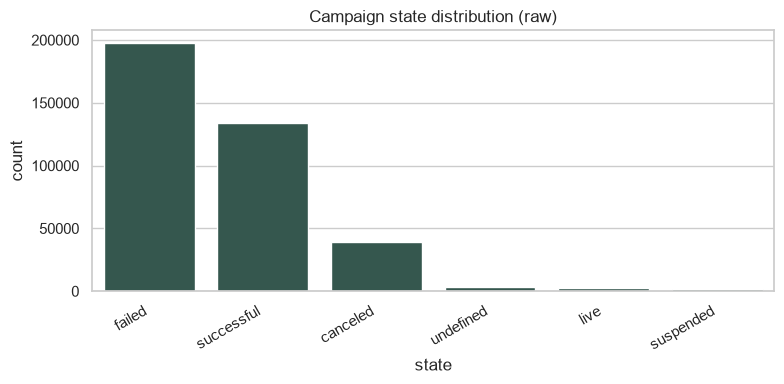

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=state_counts.index.astype(str), y=state_counts.values, ax=ax, color="#2f5d50")
ax.set_title("Campaign state distribution (raw)")
ax.set_xlabel("state")
ax.set_ylabel("count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
fig.savefig(FIG_DIR / "01_state_distribution_raw.png", dpi=150)
plt.show()

### What this figure shows

Most campaigns end as **failed** (~52%) or **successful** (~35%). The rest (`canceled`, `live`, `suspended`, `undefined`) are not useful for a clean binary funding label, so we drop them next.


In [6]:
base = df[df["state"].isin(TARGET_STATES)].copy()
base["target"] = (base["state"] == "successful").astype(int)

dropped = len(df) - len(base)
print(f"kept: {len(base):,} | dropped: {dropped:,} ({100 * dropped / len(df):.1f}%)")

target_counts = base["target"].value_counts().rename({0: "failed (0)", 1: "successful (1)"})
target_pct = (base["target"].value_counts(normalize=True) * 100).round(2).rename(
    {0: "failed (0)", 1: "successful (1)"}
)
pd.DataFrame({"count": target_counts, "pct": target_pct})

kept: 331,675 | dropped: 46,986 (12.4%)


,count,pct
target,,
failed (0),197719,59.61
successful (1),133956,40.39


### What this cut means

After keeping only `successful` / `failed`, the working set is large and still imbalanced: roughly **60% failed** vs **40% successful**. Models should be judged with Precision, Recall, and F1 — not accuracy alone.


## 3. Leakage audit

Outcome columns known after the campaign runs must not be used as features.

In [7]:
feature_plan = pd.DataFrame(
    [
        ("ID", "id", "drop — identifier"),
        ("name", "text", "use — campaign title"),
        ("category", "categorical", "use"),
        ("main_category", "categorical", "use"),
        ("currency", "categorical", "use"),
        ("country", "categorical", "use"),
        ("usd_goal_real", "numeric", "use — goal in USD"),
        ("goal", "numeric", "optional — prefer usd_goal_real"),
        ("launched", "datetime", "use — derive duration"),
        ("deadline", "datetime", "use — derive duration"),
        ("state", "target_source", "map to target, then drop"),
        ("pledged", "leakage", "exclude"),
        ("backers", "leakage", "exclude"),
        ("usd pledged", "leakage", "exclude"),
        ("usd_pledged_real", "leakage", "exclude"),
    ],
    columns=["column", "role", "decision"],
)
feature_plan

,column,role,decision
0,ID,id,drop — identifier
1,name,text,use — campaign title
2,category,categorical,use
3,main_category,categorical,use
4,currency,categorical,use
5,country,categorical,use
6,usd_goal_real,numeric,use — goal in USD
7,goal,numeric,optional — prefer usd_goal_real
8,launched,datetime,use — derive duration
9,deadline,datetime,use — derive duration


In [8]:
assert set(LEAKAGE_COLS).issubset(base.columns)
corr_with_target = (
    base[LEAKAGE_COLS + ["target"]]
    .corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(ascending=False)
)
print("Correlation of leakage columns with target (why we drop them):")
corr_with_target

Correlation of leakage columns with target (why we drop them):


backers             0.125790
pledged             0.109507
usd_pledged_real    0.108298
usd pledged         0.095658
Name: target, dtype: float64

### Why leakage matters here

`backers` and pledged amounts move strongly with the target because they are outcomes of the campaign, not inputs known at launch. Using them would inflate scores and would not reflect a real pre-funding prediction problem.


## 4. Candidate feature distributions

In [9]:
base["launched"] = pd.to_datetime(base["launched"], errors="coerce")
base["deadline"] = pd.to_datetime(base["deadline"], errors="coerce")
base["duration_days"] = (base["deadline"] - base["launched"]).dt.total_seconds() / 86400
base["name"] = base["name"].fillna("")
base["name_len"] = base["name"].str.len()
base["name_words"] = base["name"].str.split().str.len()

base[["usd_goal_real", "duration_days", "name_len", "name_words"]].describe().round(2)

,usd_goal_real,duration_days,name_len,name_words
count,3.316750e+05,331675.00,331675.00,331675.00
mean,4.151000e+04,33.39,34.22,5.63
std,1.108930e+06,12.72,15.96,2.76
min,1.000000e-02,0.01,0.00,0.00
25%,2.000000e+03,29.09,21.00,3.00
50%,5.000000e+03,29.66,33.00,5.00
75%,1.500000e+04,35.71,48.00,8.00
max,1.663614e+08,91.96,85.00,29.00


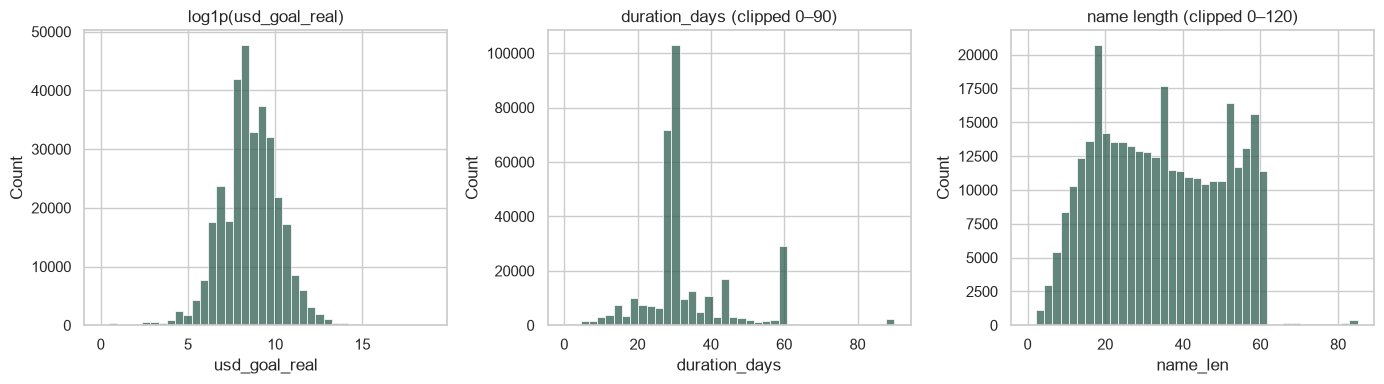

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.histplot(
    np.log1p(base["usd_goal_real"]),
    bins=40,
    ax=axes[0],
    color="#2f5d50",
)
axes[0].set_title("log1p(usd_goal_real)")

sns.histplot(base["duration_days"].clip(0, 90), bins=40, ax=axes[1], color="#2f5d50")
axes[1].set_title("duration_days (clipped 0–90)")

sns.histplot(base["name_len"].clip(0, 120), bins=40, ax=axes[2], color="#2f5d50")
axes[2].set_title("name length (clipped 0–120)")

plt.tight_layout()
fig.savefig(FIG_DIR / "01_numeric_distributions.png", dpi=150)
plt.show()

### What these distributions show

- **Goal (`usd_goal_real`):** heavily right-skewed; a log view is more readable. Most campaigns ask for modest funding, with a long tail of very large goals.
- **Duration:** clustered near ~30 days (Kickstarter’s common window), with less mass toward shorter/longer runs.
- **Title length (`name`):** typically short (about 20–50 characters). Titles carry signal, but they are brief — so TF-IDF will rely on sparse keyword cues, not long prose.


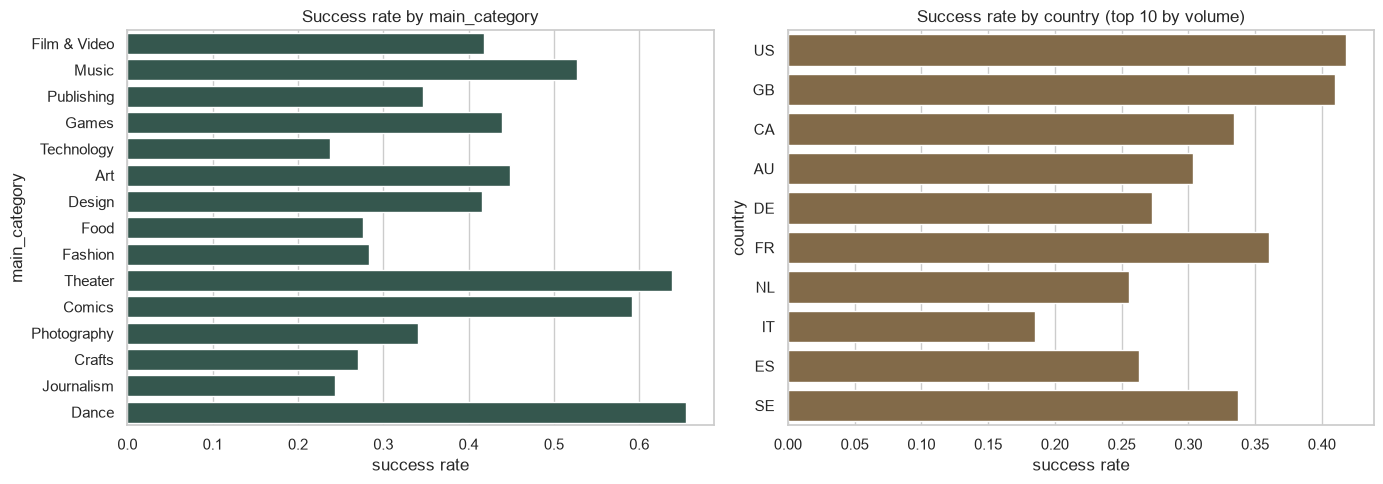

,count,success_rate
main_category,,
Film & Video,56527,0.418
Music,45949,0.527
Publishing,35445,0.347
Games,28521,0.439
Technology,27050,0.238
Art,25641,0.449
Design,25364,0.416
Food,22054,0.276
Fashion,19775,0.283


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

main_cat = (
    base.groupby("main_category")["target"]
    .agg(count="size", success_rate="mean")
    .sort_values("count", ascending=False)
)
sns.barplot(x=main_cat["success_rate"], y=main_cat.index, ax=axes[0], color="#2f5d50")
axes[0].set_title("Success rate by main_category")
axes[0].set_xlabel("success rate")

top_countries = base["country"].value_counts().head(10).index
country = (
    base[base["country"].isin(top_countries)]
    .groupby("country")["target"]
    .agg(count="size", success_rate="mean")
    .sort_values("count", ascending=False)
)
sns.barplot(x=country["success_rate"], y=country.index, ax=axes[1], color="#8c6b3f")
axes[1].set_title("Success rate by country (top 10 by volume)")
axes[1].set_xlabel("success rate")

plt.tight_layout()
fig.savefig(FIG_DIR / "01_categorical_success_rates.png", dpi=150)
plt.show()

main_cat.round(3)

### What these success rates show

Category and geography are not flat noise:

- Creative performance categories such as **Dance**, **Theater**, **Comics**, and **Music** fund more often.
- **Technology**, **Journalism**, **Food**, and **Crafts** fund less often.
- Volume is dominated by the **US**, with success rates varying across the top countries.

These gaps support keeping categorical fields in the tabular branch of the fusion model.


## 5. Data quality checks

In [12]:
quality = {
    "rows": len(base),
    "duplicate_ids": int(base["ID"].duplicated().sum()),
    "empty_names": int((base["name"].str.strip() == "").sum()),
    "nonpositive_goals": int((base["usd_goal_real"] <= 0).sum()),
    "invalid_duration": int((base["duration_days"].isna() | (base["duration_days"] <= 0)).sum()),
    "null_category": int(base["category"].isna().sum()),
    "null_country": int(base["country"].isna().sum()),
}
pd.Series(quality, name="value")

rows                 331675
duplicate_ids             0
empty_names               3
nonpositive_goals         0
invalid_duration          0
null_category             0
null_country              0
Name: value, dtype: int64

## 6. Save interim base table

Save the filtered binary dataset with derived fields for Phase 2+.

In [13]:
keep_cols = [
    "ID",
    "name",
    "category",
    "main_category",
    "currency",
    "country",
    "launched",
    "deadline",
    "usd_goal_real",
    "duration_days",
    "name_len",
    "name_words",
    "state",
    "target",
]

interim = base[keep_cols].copy()
interim = interim[interim["usd_goal_real"] > 0]
interim = interim[interim["duration_days"] > 0]
interim = interim[interim["name"].str.strip() != ""]

interim.to_csv(INTERIM_PATH, index=False)
print(f"saved: {INTERIM_PATH}")
print(f"rows: {len(interim):,} | success rate: {interim['target'].mean():.3f}")
interim.head()

saved: /Users/koriginjasathvik/Desktop/ML_Summer_Project/data/interim/ks_binary_base.csv
rows: 331,672 | success rate: 0.404


,ID,name,category,main_category,currency,country,launched,deadline,usd_goal_real,duration_days,name_len,name_words,state,target
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,GB,2015-08-11 12:12:28,2015-10-09,1533.95,58.491343,31,6,failed,0
1,1000003930,Greeting From Earth: ZGAC Arts Capsule For ET,Narrative Film,Film & Video,USD,US,2017-09-02 04:43:57,2017-11-01,30000.00,59.802813,45,8,failed,0
2,1000004038,Where is Hank?,Narrative Film,Film & Video,USD,US,2013-01-12 00:20:50,2013-02-26,45000.00,44.985532,14,3,failed,0
3,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,US,2012-03-17 03:24:11,2012-04-16,5000.00,29.858206,49,7,failed,0
5,1000014025,Monarch Espresso Bar,Restaurants,Food,USD,US,2016-02-26 13:38:27,2016-04-01,50000.00,34.431632,20,3,successful,1


## Phase 1 takeaways

- Binary target locked: `successful=1`, `failed=0`.
- Outcome columns (`pledged`, `backers`, `usd pledged`, `usd_pledged_real`) are leakage and stay out of features.
- Modeling inputs going forward: cleaned `name` + tabular metadata (`usd_goal_real`, `duration_days`, category fields, `currency`, `country`).
- Class mix is ~60/40 failed/successful — use Precision/Recall/F1 in evaluation.
- Category and country show real success-rate spread; goals are skewed; titles are short.
- Interim file: `data/interim/ks_binary_base.csv`.
- Figure readings are summarized in [`docs/eda-findings.md`](../docs/eda-findings.md).
